# 05 · Role clustering

Group all 10,040 tech postings (labeled or not) into **role types**, with no labels involved.

Training runs in `src/models/train_clusters.py` (`python -m src.models.train_clusters`, ~2 min). This notebook loads the saved model and assignments.

**Pipeline:** title ×3 + description (company name removed) → TF-IDF (1–2 word phrases) → TruncatedSVD (100 dims) → L2-normalize → KMeans

- **TF-IDF + SVD = LSA.** SVD compresses 20k sparse word features into 100 dense "topics". After L2-normalization, KMeans' Euclidean distance is equivalent to cosine similarity, which is the usual similarity measure for text.
- **HR boilerplate stop words.** The first attempt produced 2 of 8–10 clusters (≈3,300 postings) defined by *status, disability, gender, benefits*, i.e. by equal-opportunity templates, not by role. A domain stop-word list (`BOILERPLATE_STOP_WORDS` in `src/features/text.py`) removes these words.
- **Title ×3.** The title names the role in a few words, while the description is hundreds of words. Repeating the title gives it more weight without dropping the description, which the app needs for pasted descriptions that have no title.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.features.skills import SKILL_NAMES, skill_column

viz.set_style()
pd.set_option("display.max_colwidth", 110)

C = json.loads((ROOT / "reports" / "metrics.json").read_text())["clusters"]
bundle = joblib.load(ROOT / "models" / "clusters.joblib")
NAMES = bundle["names"]
jobs = pd.read_parquet(ROOT / "data" / "processed" / "jobs.parquet")
assign = pd.read_parquet(ROOT / "data" / "processed" / "clusters.parquet")
assert (assign["job_id"].to_numpy() == jobs["job_id"].to_numpy()).all()
jobs = jobs.join(assign.drop(columns="job_id"))
skills = pd.read_parquet(ROOT / "data" / "processed" / "skills.parquet")
S = skills.drop(columns="skill_count").rename(columns={skill_column(n): n for n in SKILL_NAMES})
order = jobs["cluster_name"].value_counts().index  # largest first
print(f"k = {C['k']}, LSA explained variance = {C['explained_variance']:.2f}")

k = 10, LSA explained variance = 0.18


## 1. Choosing k (4–15)

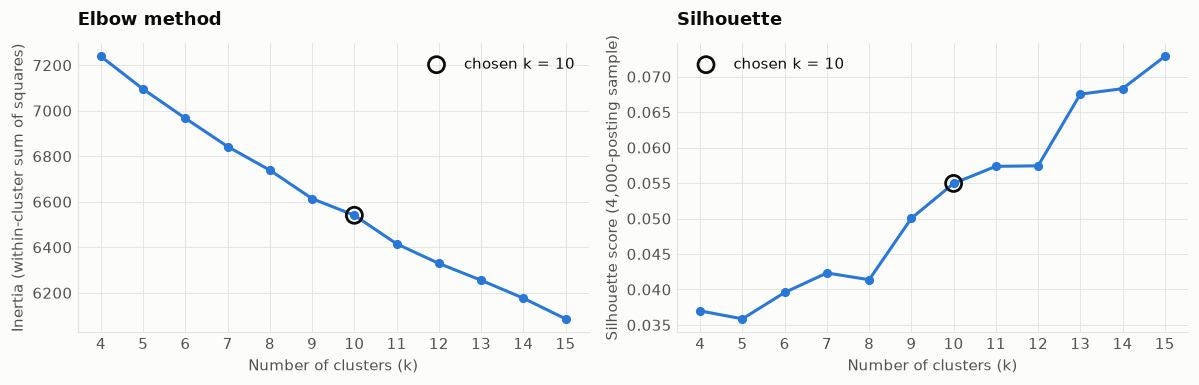

k,4,5,6,7,8,9,10,11,12,13,14,15
inertia,7238.3809,7094.5122,6966.5083,6842.4404,6738.7520,6613.543,6540.6016,6415.2207,6329.1514,6255.1167,6176.5317,6085.4893
silhouette,0.0370,0.0359,0.0396,0.0423,0.0414,0.050,0.0549,0.0574,0.0574,0.0675,0.0683,0.0728


In [2]:
scan = pd.DataFrame(C["k_scan"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col, label in [(axes[0], "inertia", "Inertia (within-cluster sum of squares)"),
                       (axes[1], "silhouette", "Silhouette score (4,000-posting sample)")]:
    ax.plot(scan["k"], scan[col], color=viz.BLUE, marker="o", markersize=5)
    chosen = scan.loc[scan["k"] == C["k"]]
    ax.scatter(chosen["k"], chosen[col], s=110, facecolor="none", edgecolor=viz.TEXT_PRIMARY, linewidth=1.8, zorder=3,
               label=f"chosen k = {C['k']}")
    ax.set_xticks(scan["k"])
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel(label)
    ax.legend(loc="upper right" if col == "inertia" else "upper left")
axes[0].set_title("Elbow method")
axes[1].set_title("Silhouette")
fig.tight_layout()
viz.save(fig, "18_choose_k")
plt.show()
scan.round(4).set_index("k").T

**Why k = 10:** There is no clean elbow: inertia falls almost linearly. Silhouette keeps rising up to k=15, and every value stays low (0.04–0.07). This is normal for text, where role types overlap (a "data engineer" and a "BI developer" share much vocabulary). So k is a modeling choice, not something the data dictates. The largest silhouette gain is from k=8 to k=10 (0.041 → 0.055). At k=10 every cluster is a recognizable role type. Beyond 10, the new clusters split on tone rather than role: k=11 adds a cluster built on *make, best, life, health*, and k=12 a mixed *test, quality, functional* cluster.

## 2. The clusters and their names

Names come from each centroid's top TF-IDF terms (the centroid mapped back from SVD space to word space) and the most common titles. **Please confirm or suggest better names.**

In [3]:
rows = []
for c in C["clusters"]:
    titles = jobs.loc[jobs["cluster"] == c["id"], "title"].str.lower().value_counts().head(4).index
    rows.append({"id": c["id"], "name": c["name"], "postings": c["size"],
                 "top terms": ", ".join(c["top_terms"][:9]), "most common titles": "; ".join(titles)})
clusters = pd.DataFrame(rows).sort_values("postings", ascending=False).set_index("id")
clusters

,name,postings,top terms,most common titles
id,,,,
6,"Software, Cloud & QA Engineering",2198,"engineer, software engineer, cloud, devops, test, automation, engineering, database, testing",software engineer; senior software engineer; devops engineer; database administrator
2,Software Engineering (Product),2094,"engineer, engineering, software engineer, best, make, quality, life, senior, ll",senior software engineer; software engineer; staff software engineer; full stack engineer
1,Application Development (Java/.NET/Web),1844,"developer, java, web, using, net, applications, end, sql, code",java developer; python developer; full stack engineer; dotnet developer
4,Network & Systems Administration,700,"network, administrator, network engineer, engineer, cisco, infrastructure, security, networking, administr...",network engineer; senior network engineer; system administrator; system engineer
7,Data Engineering & BI,606,"data engineer, sql, engineer, etl, bi, analytics, azure, snowflake, engineer data",data engineer; senior data engineer; power bi developer; business intelligence developer
0,Data Science & ML,578,"machine learning, machine, ai, learning, scientist, data scientist, models, ml, data science",data scientist; machine learning engineer; senior data scientist; senior machine learning engineer
5,Data & Business Analysis,576,"analyst, data analyst, analyst data, analysis, reporting, reports, analytics, sql, data analysis",data analyst; senior data analyst; business system analyst; business systems analyst
9,Solutions & Cloud Architecture,528,"architect, architecture, cloud, enterprise, aws, security, azure, cloud architect, data architect",solutions architect; cloud architect; solution architect; java architect
8,Cybersecurity,507,"security, cyber, cybersecurity, security engineer, cyber security, risk, vulnerability, security analyst, ...",cyber security engineer; security engineer; cyber security analyst; information security engineer


**Takeaway:** Eight clusters are clearly distinct roles: Data Science & ML, Data Engineering & BI, Data & Business Analysis, Cybersecurity, Network & Systems Administration, IT Support & Help Desk, Solutions & Cloud Architecture, and Application Development (Java/.NET/Web). The two largest clusters (≈2,100 postings each) are both general software engineering and are the least crisp. *Software, Cloud & QA Engineering* leans towards DevOps, test automation and databases. *Software Engineering (Product)* is product-company SWE postings, written in a mission/culture tone (*make, best, life*).

## 3. 2D map (t-SNE)

t-SNE squeezes the 100-dimensional LSA vectors into 2D while trying to keep neighbors together. With 10 clusters one colored scatter would need 10 hues that are hard to tell apart, so each panel highlights one cluster against all the others.

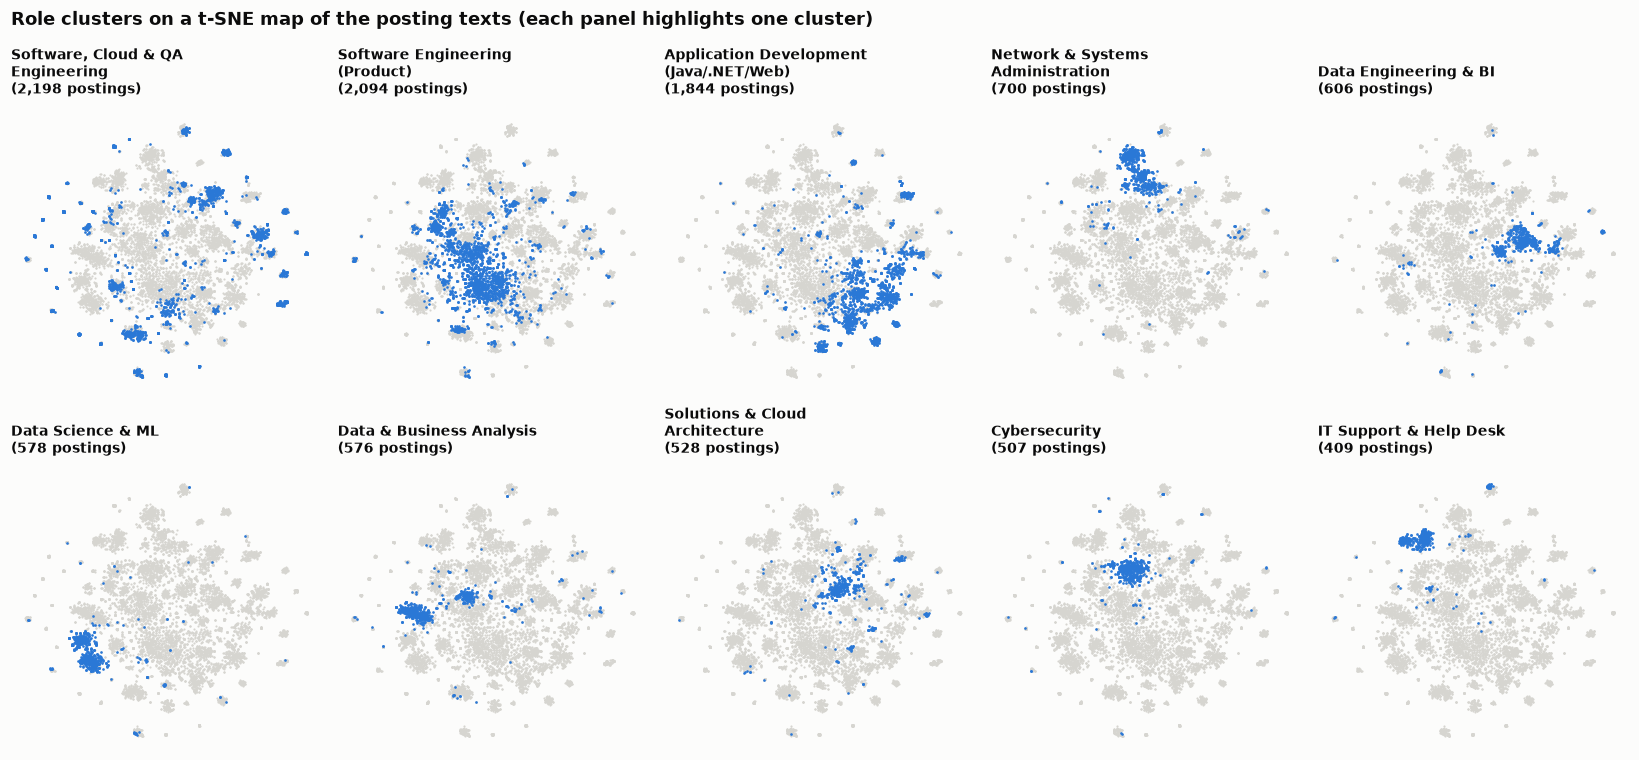

In [4]:
import textwrap

fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharex=True, sharey=True)
for ax, name in zip(axes.ravel(), order):
    mine = jobs["cluster_name"] == name
    ax.scatter(jobs.loc[~mine, "tsne_x"], jobs.loc[~mine, "tsne_y"], s=2, color="#d6d5d0", linewidths=0, rasterized=True)
    ax.scatter(jobs.loc[mine, "tsne_x"], jobs.loc[mine, "tsne_y"], s=3, color=viz.BLUE, linewidths=0, rasterized=True)
    ax.set_title(f"{textwrap.fill(name, 26)}\n({mine.sum():,} postings)", fontsize=9, loc="left")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle("Role clusters on a t-SNE map of the posting texts (each panel highlights one cluster)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "19_cluster_map")
plt.show()

**Takeaway:** The specialist clusters (Data Science & ML, Cybersecurity, IT Support, Network, Data & Business Analysis) form tight islands. The two general software clusters and Application Development are spread across the middle and overlap each other, which matches their low silhouette. Software work is one continuum, not three separate groups.

## 4. Cluster profiles

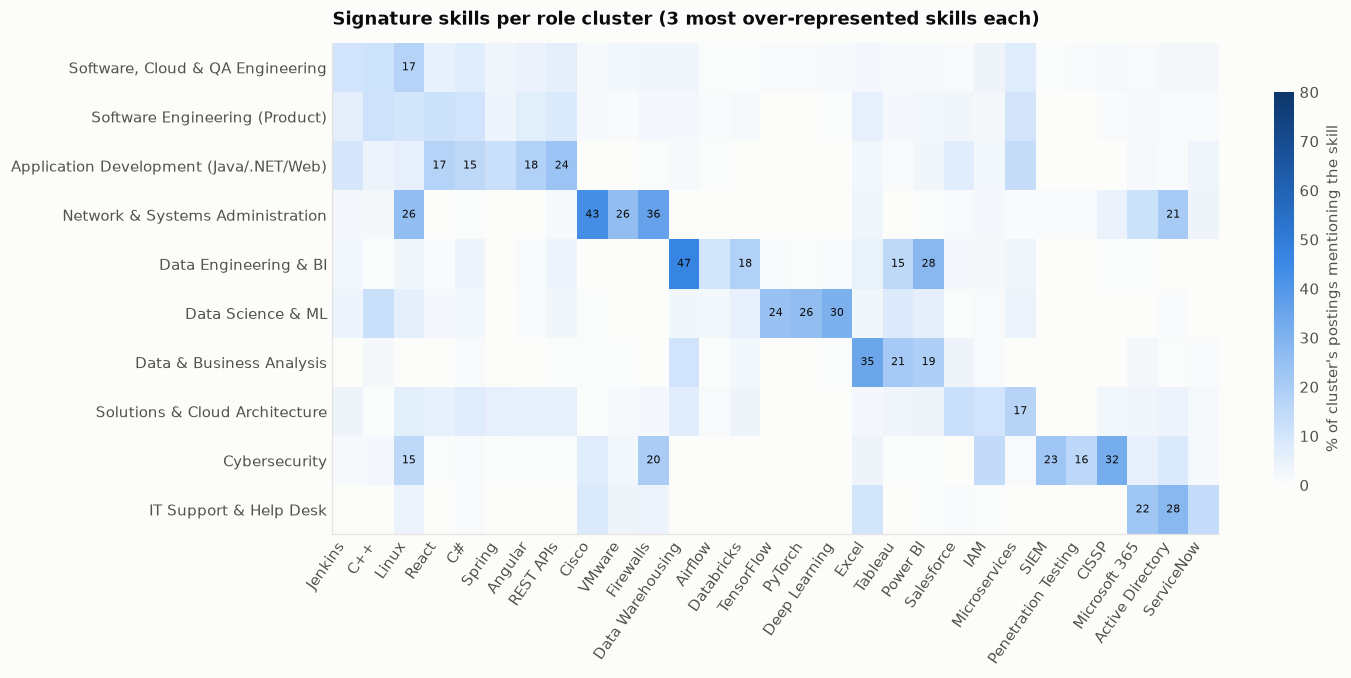

In [5]:
# Share of postings in each cluster that mention a skill: the 3 most distinctive skills per cluster
share = S.groupby(jobs["cluster_name"]).mean().mul(100).loc[order]
lift = share / S.mean().mul(100).replace(0, np.nan)
picked = []
for name in order:
    for skill in (lift.loc[name] * (share.loc[name] >= 10)).sort_values(ascending=False).index[:3]:
        if skill not in picked:
            picked.append(skill)
H = share[picked]

fig, ax = plt.subplots(figsize=(13, 5.8))
im = ax.imshow(H.to_numpy(), cmap=viz.SEQUENTIAL, vmin=0, vmax=80, aspect="auto")
ax.set_xticks(range(len(picked)), picked, rotation=55, ha="right")
ax.set_yticks(range(len(order)), order)
ax.grid(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.iat[i, j]
        if v >= 15:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v >= 50 else viz.TEXT_PRIMARY)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("% of cluster's postings mentioning the skill")
cbar.outline.set_visible(False)
ax.set_title("Signature skills per role cluster (3 most over-represented skills each)")
viz.save(fig, "20_cluster_skills")
plt.show()

**Takeaway:** Each specialist cluster has clear signature skills: Data Science & ML → Deep Learning / PyTorch / TensorFlow (24–30%), Data Engineering & BI → Data Warehousing (47%) + Power BI, Network → Cisco (43%) + Firewalls, Cybersecurity → CISSP / SIEM, IT Support → Active Directory / Microsoft 365, Analysts → Excel (35%). The general software clusters have no signature skill above 17%. They ask for broad stacks, which is also why they are hard to separate.

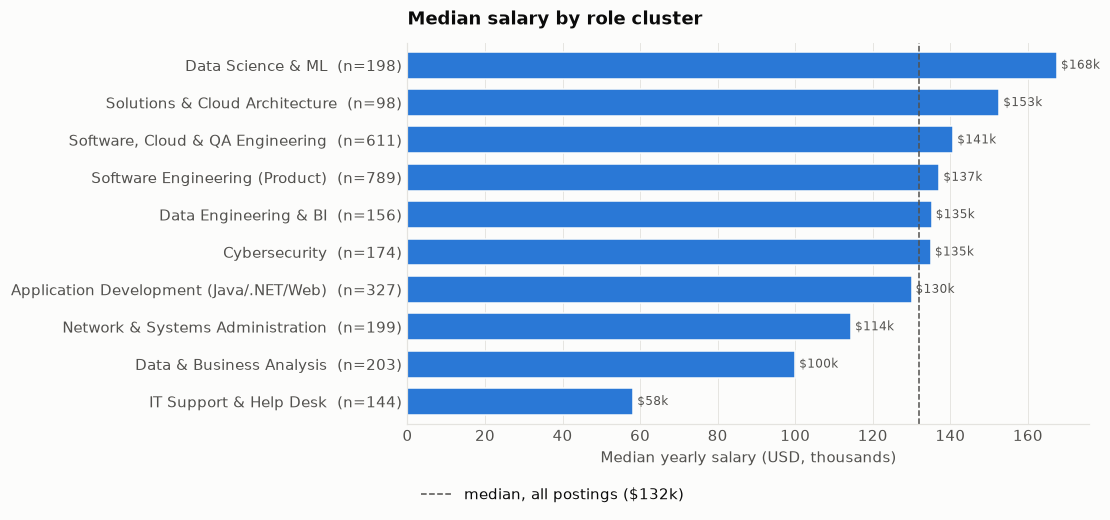

In [6]:
sal = jobs.dropna(subset=["salary_yearly"]).groupby("cluster_name")["salary_yearly"].agg(["median", "size"])
sal = sal.sort_values("median", ascending=False)
overall = jobs["salary_yearly"].median()

fig, ax = plt.subplots(figsize=(8, 4.5))
viz.barh(ax, [f"{n}  (n={s})" for n, s in zip(sal.index, sal["size"])], sal["median"] / 1000, fmt="${:.0f}k")
ax.axvline(overall / 1000, color=viz.TEXT_SECONDARY, linestyle="--", linewidth=1, label=f"median, all postings (${overall / 1000:.0f}k)")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.13))
ax.set_title("Median salary by role cluster")
ax.set_xlabel("Median yearly salary (USD, thousands)")
viz.save(fig, "21_cluster_salary")
plt.show()

**Takeaway:** Data Science & ML pays the most (median $168k), followed by Solutions & Cloud Architecture ($153k). IT Support & Help Desk is by far the lowest ($58k), and Data & Business Analysis is at $100k. The spread between role types (≈$110k) is larger than the spread between states (≈$49k) in the EDA.

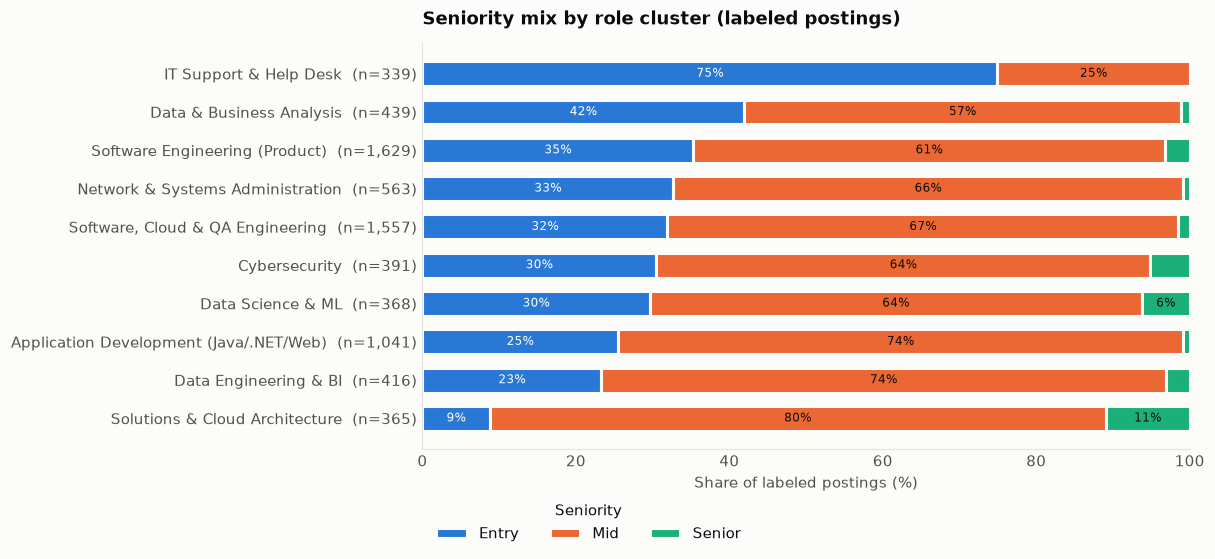

In [7]:
mix = pd.crosstab(jobs["cluster_name"], jobs["seniority"], normalize="index").reindex(columns=viz.SENIORITY_ORDER) * 100
labeled_n = jobs.groupby("cluster_name")["seniority"].count()
mix = mix.loc[mix.sort_values("Entry", ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 4.8))
left = np.zeros(len(mix))
for level in viz.SENIORITY_ORDER:
    ax.barh(mix.index, mix[level], left=left, color=viz.SENIORITY_COLORS[level], height=0.65,
            edgecolor=viz.SURFACE, linewidth=2, label=level)
    for i, (l, v) in enumerate(zip(left, mix[level])):
        if v >= 6:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                    color="white" if level == "Entry" else viz.TEXT_PRIMARY)
    left += mix[level].to_numpy()
ax.set_yticks(range(len(mix)), [f"{n}  (n={labeled_n[n]:,})" for n in mix.index])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.grid(False)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.1), title="Seniority")
ax.set_title("Seniority mix by role cluster (labeled postings)")
ax.set_xlabel("Share of labeled postings (%)")
viz.save(fig, "22_cluster_seniority")
plt.show()

**Takeaway:** IT Support is 75% Entry, the main entry point into tech in this data, followed by Data & Business Analysis (42% Entry). Solutions & Cloud Architecture is the most senior role type (only 9% Entry, 11% Senior), which makes sense because architects are typically promoted engineers. For an intern or new grad, the most accessible clusters are IT support, analyst and general software engineering roles.

In [8]:
profile = pd.DataFrame({
    "postings": jobs["cluster_name"].value_counts(),
    "median salary": jobs.groupby("cluster_name")["salary_yearly"].median().round(-3),
    "% remote": jobs.groupby("cluster_name")["work_type"].apply(lambda s: (s == "remote").mean() * 100).round(1),
    "% Entry (labeled)": mix["Entry"].round(1),
    "avg skills listed": skills["skill_count"].groupby(jobs["cluster_name"]).mean().round(1),
}).loc[order]
profile

,postings,median salary,% remote,% Entry (labeled),avg skills listed
cluster_name,,,,,
"Software, Cloud & QA Engineering",2198,141000.0,22.3,31.9,6.4
Software Engineering (Product),2094,137000.0,25.5,35.3,6.1
Application Development (Java/.NET/Web),1844,130000.0,30.3,25.5,7.1
Network & Systems Administration,700,114000.0,15.1,32.7,5.1
Data Engineering & BI,606,135000.0,30.7,23.3,8.1
Data Science & ML,578,168000.0,30.6,29.6,8.3
Data & Business Analysis,576,100000.0,22.6,41.9,3.6
Solutions & Cloud Architecture,528,153000.0,36.2,8.8,5.5
Cybersecurity,507,135000.0,24.9,30.4,4.8


## 5. Try it: cluster a pasted description (no title)

In [9]:
examples = pd.DataFrame({
    "title": ["", "", ""],
    "description": [
        "Build and deploy machine learning models with PyTorch. Research on LLMs and NLP.",
        "Troubleshoot hardware, Windows and printer issues for end users; manage tickets in ServiceNow.",
        "Build React and TypeScript front ends backed by Node.js REST APIs.",
    ],
})
pd.DataFrame({"description": examples["description"],
              "cluster": [NAMES[c] for c in bundle["pipeline"].predict(examples)]})

,description,cluster
0,Build and deploy machine learning models with PyTorch. Research on LLMs and NLP.,Data Science & ML
1,"Troubleshoot hardware, Windows and printer issues for end users; manage tickets in ServiceNow.",IT Support & Help Desk
2,Build React and TypeScript front ends backed by Node.js REST APIs.,Application Development (Java/.NET/Web)


## Summary

- **10 role clusters** from TF-IDF → SVD(100) → KMeans on title ×3 + description. HR boilerplate stop words were needed to stop postings clustering by their equal-opportunity templates.
- **k = 10** was chosen for interpretability plus the largest silhouette gain (k=8 → 10). The low silhouette values (≈0.05) are expected for overlapping text categories and are reported honestly.
- **Specialist roles are distinct**, with clear skill signatures: ML (PyTorch/TensorFlow), Data Engineering (warehousing, Power BI), Network (Cisco), Security (CISSP, SIEM), IT Support (Active Directory). **General software engineering is a continuum** split into three overlapping clusters.
- **Pay and seniority differ by role:** Data Science & ML has the highest median ($168k) and IT Support the lowest ($58k, 75% Entry). Architecture is the most senior role type.
- **Saved:** `models/clusters.joblib` (a full pipeline from raw title/description to cluster id, plus names). It works on a pasted description without a title, which the app needs.